# MTG Card Long-Run Spike Research

**Research question:** After the initial post-release price decline, how likely is a rare or mythic card to spike massively in the long run?

**Methodology:**
- Pull 2 years (730 days) of nonfoil price history per card
- Detect each card's **post-release bottom**: minimum smoothed price within the first 90 days
- A **spike** = smoothed price reaches N× the bottom price at any point after the bottom
- Thresholds: **2×**, **3×**, **5×**

Scope: regular expansion sets, 2021–present, rare + mythic only, nonfoil.

---

In [24]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
SPIKE_PARQUET = DATA_DIR / "card_spike_window.parquet"
REFRESH = False # set True to re-query the DB

RARITY_COLORS = {"mythic": "#e07b39", "rare": "#c5a800"}
RARITY_ORDER  = ["mythic", "rare"]

DB_CONFIG = dict(
    host="localhost",
    port=5433,
    dbname="automana",
    user="automana_admin",
    password=os.environ.get("AUTOMANA_DB_PASSWORD", ""),
)

def get_conn():
    return psycopg2.connect(**DB_CONFIG)

def query_to_df(sql, date_cols=("released_at", "price_date")):
    """Execute via psycopg2 cursor — avoids pandas DBAPI2 silent failures."""
    with get_conn() as conn:
        cur = conn.cursor()
        cur.execute(sql)
        cols = [d[0] for d in cur.description]
        rows = cur.fetchall()
    df = pd.DataFrame(rows, columns=cols)
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])
    return df

**Cell below:** Pull 730 days of price history for all rare and mythic cards in expansion sets.
Saved to `data/card_spike_window.parquet`; set `REFRESH = True` to re-query after new data is ingested.

> Note: sets released less than 2 years ago will have fewer than 730 days of data.
> Their spike rates are underestimates — a card that hasn't had time to spike yet simply shows up as "no spike".

In [25]:
SQL = """
SELECT
    s.set_code,
    s.set_name,
    s.released_at,
    r.rarity_name,
    cv.card_version_id,
    ppd.price_date,
    (ppd.price_date - s.released_at)::int AS days_since_release,
    ppd.list_low_cents
FROM pricing.print_price_daily ppd
JOIN card_catalog.card_version cv       ON cv.card_version_id = ppd.card_version_id
JOIN card_catalog.rarities_ref r        ON r.rarity_id = cv.rarity_id
JOIN card_catalog.sets s                ON s.set_id = cv.set_id
JOIN card_catalog.set_type_list_ref st  ON st.set_type_id = s.set_type_id
WHERE st.set_type = 'expansion'
  AND s.released_at BETWEEN '2015-01-01' AND CURRENT_DATE
  AND ppd.price_date >= s.released_at
  AND ppd.price_date <= s.released_at + INTERVAL '730 days'
  AND ppd.finish_id = 1
  AND ppd.list_low_cents IS NOT NULL
  AND ppd.list_low_cents > 0
  AND r.rarity_name IN ('rare', 'mythic')
"""

if REFRESH or not SPIKE_PARQUET.exists():
    print("Querying DB (rare + mythic, 2-year window)…")
    raw = query_to_df(SQL)
    raw.to_parquet(SPIKE_PARQUET, index=False)
    print(f"Saved {len(raw):,} rows → {SPIKE_PARQUET}")
else:
    raw = pd.read_parquet(SPIKE_PARQUET)
    print(f"Loaded {len(raw):,} rows from {SPIKE_PARQUET}")

print(f"\nSets: {raw['set_code'].nunique()}  |  Cards: {raw['card_version_id'].nunique():,}")
print(raw.groupby("rarity_name")["card_version_id"].nunique().rename("unique_cards"))

Loaded 2,539,624 rows from data/card_spike_window.parquet

Sets: 29  |  Cards: 4,539
rarity_name
mythic    1194
rare      3345
Name: unique_cards, dtype: int64


In [26]:
# How many days of data does each set have?
# Sets released < 2 years ago will show max_day < 730 — their spike rates are lower bounds.
coverage = (
    raw.groupby(["set_code", "set_name", "released_at"])
    .agg(max_day=("days_since_release", "max"), cards=("card_version_id", "nunique"))
    .sort_values("released_at")
)
display(coverage)

,,,max_day,cards
set_code,set_name,released_at,,
eld,Throne of Eldraine,2019-10-04,730,159
thb,Theros Beyond Death,2020-01-24,730,146
iko,Ikoria: Lair of Behemoths,2020-04-24,730,147
znr,Zendikar Rising,2020-09-25,730,167
khm,Kaldheim,2021-02-05,730,165
stx,Strixhaven: School of Mages,2021-04-23,730,180
afr,Adventures in the Forgotten Realms,2021-07-23,730,153
mid,Innistrad: Midnight Hunt,2021-09-24,730,169
vow,Innistrad: Crimson Vow,2021-11-19,730,183


---

## Part 1 — Post-Release Bottom Detection

We need a **baseline price** to measure spikes against. Rather than using day-0 (which is inflated by pre-order hype), we use each card's **post-release floor**: the lowest smoothed price within the first 90 days.

This is the true starting point for a "long-run spike" — a card that doubles from its floor is actually interesting. A card that recovers from a 90% day-0 drop to half its release price is not.

In [27]:
# Daily median per card
card_daily = (
    raw.groupby(["set_code", "rarity_name", "card_version_id", "days_since_release"])
    ["list_low_cents"]
    .median()
    .reset_index(name="daily_cents")
)

# Build smoothed curve per card — reindex to full calendar range before rolling
# (same approach as main notebook: fills calendar-day gaps so rolling operates correctly)
print("Building smoothed curves per card (this takes ~1 min)…")
groups = []
for (set_code, rarity, card_id), g in card_daily.groupby(
    ["set_code", "rarity_name", "card_version_id"], sort=False
):
    max_day = int(g["days_since_release"].max())
    g_idx = g.set_index("days_since_release").reindex(range(0, max_day + 1))
    g_idx["smoothed"] = g_idx["daily_cents"].rolling(7, min_periods=3, center=True).median()
    g_idx["set_code"]      = set_code
    g_idx["rarity_name"]   = rarity
    g_idx["card_version_id"] = card_id
    groups.append(g_idx.reset_index())

card_curves = pd.concat(groups, ignore_index=True).dropna(subset=["daily_cents"])
print(f"Unique cards with curves: {card_curves['card_version_id'].nunique():,}")

Building smoothed curves per card (this takes ~1 min)…
Unique cards with curves: 4,539


In [28]:
BOTTOM_WINDOW = 90  # look for the floor within the first 90 days post-release

bottom_records = []
for (set_code, rarity, card_id), g in card_curves.groupby(
    ["set_code", "rarity_name", "card_version_id"], sort=False
):
    early = g[g["days_since_release"] <= BOTTOM_WINDOW].dropna(subset=["smoothed"])
    if len(early) < 3:
        continue
    idx = early["smoothed"].idxmin()
    bottom_records.append({
        "set_code":       set_code,
        "rarity_name":    rarity,
        "card_version_id": card_id,
        "bottom_day":     int(early.loc[idx, "days_since_release"]),
        "bottom_cents":   float(early.loc[idx, "smoothed"]),
        "max_day":        int(g["days_since_release"].max()),
    })

bottoms = pd.DataFrame(bottom_records)
print(f"Cards with detected bottom: {len(bottoms):,}")
print("\nBottom day distribution by rarity:")
print(bottoms.groupby("rarity_name")["bottom_day"].describe().round(1))

Cards with detected bottom: 3,752

Bottom day distribution by rarity:
              count  mean   std  min   25%   50%   75%   max
rarity_name                                                 
mythic       1003.0  57.3  30.1  0.0  38.0  67.0  83.0  90.0
rare         2749.0  43.5  28.4  0.0  20.0  45.0  69.0  90.0


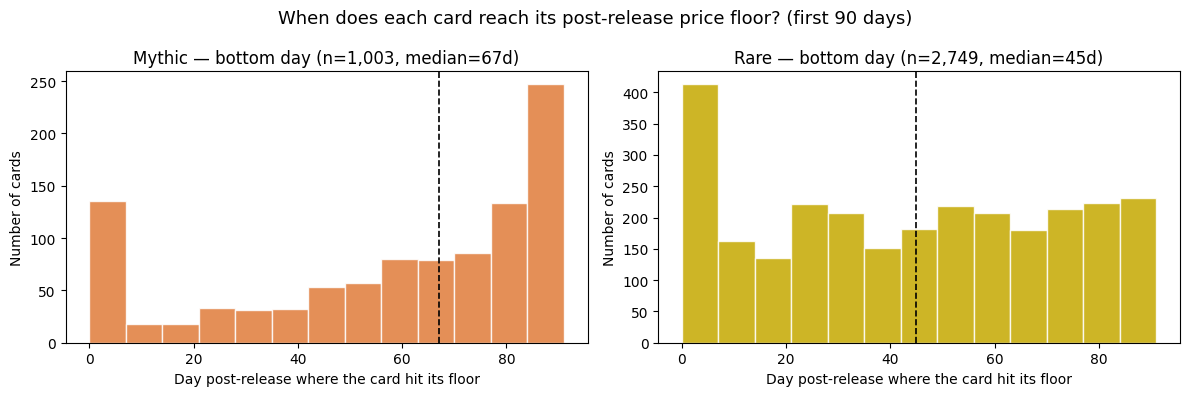

In [29]:
# Sanity check: distribution of bottom days per rarity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, rarity in enumerate(RARITY_ORDER):
    ax = axes[i]
    sub = bottoms[bottoms["rarity_name"] == rarity]
    ax.hist(sub["bottom_day"], bins=range(0, 95, 7),
            color=RARITY_COLORS[rarity], alpha=0.85, edgecolor="white")
    med = int(sub["bottom_day"].median())
    ax.axvline(med, color="black", linestyle="--", linewidth=1.2)
    ax.set_title(f"{rarity.capitalize()} — bottom day (n={len(sub):,}, median={med}d)")
    ax.set_xlabel("Day post-release where the card hit its floor")
    ax.set_ylabel("Number of cards")

fig.suptitle("When does each card reach its post-release price floor? (first 90 days)", fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / "spike_sanity_bottom_dist.png", dpi=150)
plt.show()

---

## Part 2 — Spike Detection

A **spike** is defined as: the card's smoothed price reaches **N×** its post-release floor at any point after the floor, within the 2-year window.

We record:
- Whether the card ever hit 2×, 3×, 5× its bottom
- On which day the threshold was first crossed
- The card's **maximum ratio** (peak price / bottom price) across the full window

The 7-day rolling median smoothing already filters single-day noise. No additional persistence requirement is applied — the first day the smoothed price crosses the threshold counts.

In [30]:
SPIKE_THRESHOLDS = [2.0, 3.0, 5.0]

# Attach bottom info to each post-bottom row (vectorised merge, avoids per-card table scan)
post_bottom = card_curves.merge(
    bottoms[["set_code", "card_version_id", "bottom_day", "bottom_cents"]],
    on=["set_code", "card_version_id"],
    how="inner",
)
post_bottom = (
    post_bottom[post_bottom["days_since_release"] > post_bottom["bottom_day"]]
    .dropna(subset=["smoothed"])
    .copy()
)
post_bottom["ratio"] = post_bottom["smoothed"] / post_bottom["bottom_cents"]
print(f"Post-bottom rows: {len(post_bottom):,}")

spike_records = []
for (set_code, rarity, card_id), g in post_bottom.groupby(
    ["set_code", "rarity_name", "card_version_id"], sort=False
):
    g_sorted = g.sort_values("days_since_release")
    rec = {
        "set_code":        set_code,
        "rarity_name":     rarity,
        "card_version_id": card_id,
        "max_ratio":       float(g_sorted["ratio"].max()),
        "max_ratio_day":   int(g_sorted.loc[g_sorted["ratio"].idxmax(), "days_since_release"]),
        "max_day":         int(g_sorted["days_since_release"].max()),
    }
    for thresh in SPIKE_THRESHOLDS:
        above = g_sorted[g_sorted["ratio"] >= thresh]
        if not above.empty:
            rec[f"spike_{int(thresh)}x"] = True
            rec[f"spike_{int(thresh)}x_day"] = int(above["days_since_release"].iloc[0])
        else:
            rec[f"spike_{int(thresh)}x"] = False
            rec[f"spike_{int(thresh)}x_day"] = np.nan
    spike_records.append(rec)

spikes = pd.DataFrame(spike_records)
print(f"\nSpike analysis complete: {len(spikes):,} cards")

Post-bottom rows: 2,066,829

Spike analysis complete: 3,752 cards


In [31]:
# Summary table: spike rates and peak multiples
rate_table = spikes.groupby("rarity_name").agg(
    cards=("card_version_id", "count"),
    pct_2x=("spike_2x", lambda x: f"{x.mean()*100:.1f}%"),
    pct_3x=("spike_3x", lambda x: f"{x.mean()*100:.1f}%"),
    pct_5x=("spike_5x", lambda x: f"{x.mean()*100:.1f}%"),
    median_max=("max_ratio", lambda x: f"{x.median():.2f}×"),
    p90_max=("max_ratio", lambda x: f"{x.quantile(0.9):.2f}×"),
).loc[RARITY_ORDER]
rate_table.columns = ["Cards", "Hit 2×", "Hit 3×", "Hit 5×", "Median peak", "90th pct peak"]
display(rate_table)

,Cards,Hit 2×,Hit 3×,Hit 5×,Median peak,90th pct peak
rarity_name,,,,,,
mythic,1003,32.4%,18.2%,8.9%,1.50×,4.51×
rare,2749,65.5%,43.3%,25.7%,2.50×,10.00×


---

## Part 3 — Figures

Four charts answering the core questions:
- **Figure A:** What fraction of rare/mythic cards ever spike at each threshold?
- **Figure B:** When do spikes tend to happen (timing distribution)?
- **Figure C:** How high do cards peak overall? (survival function of max ratio)
- **Figure D:** Do spikes stick, or do cards crash back to the floor?

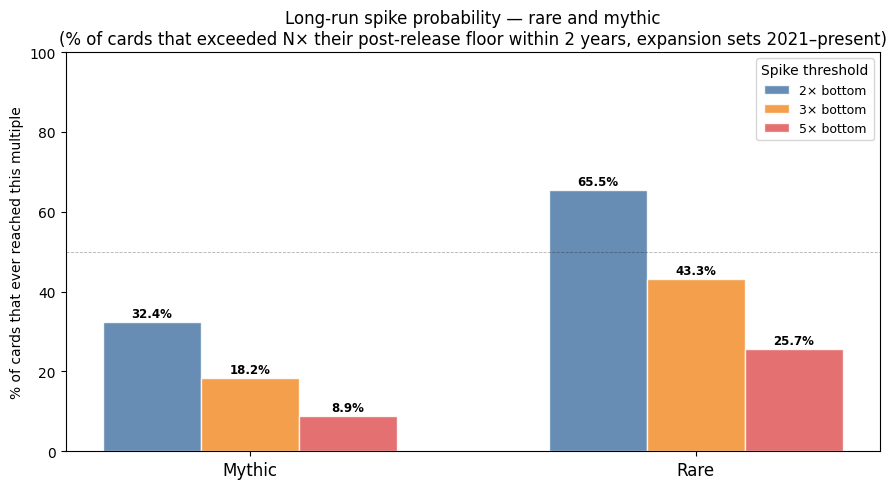

In [32]:
# Figure A — Spike probability by threshold and rarity
THRESH_COLORS = {2: "#4e79a7", 3: "#f28e2b", 5: "#e15759"}

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(RARITY_ORDER))
width = 0.22

for i, thresh in enumerate(SPIKE_THRESHOLDS):
    rates = [
        spikes[spikes["rarity_name"] == r][f"spike_{int(thresh)}x"].mean() * 100
        for r in RARITY_ORDER
    ]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, rates, width, label=f"{int(thresh)}\u00d7 bottom",
                  color=THRESH_COLORS[int(thresh)], alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f"{v:.1f}%",
                ha="center", va="bottom", fontsize=8.5, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([r.capitalize() for r in RARITY_ORDER], fontsize=12)
ax.set_ylabel("% of cards that ever reached this multiple")
ax.set_title(
    "Long-run spike probability — rare and mythic\n"
    "(% of cards that exceeded N\u00d7 their post-release floor within 2 years, expansion sets 2021\u2013present)"
)
ax.legend(title="Spike threshold", fontsize=9)
ax.set_ylim(0, 100)
ax.axhline(50, color="black", linestyle="--", linewidth=0.6, alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_DIR / "spike_figA_probability.png", dpi=150)
plt.show()

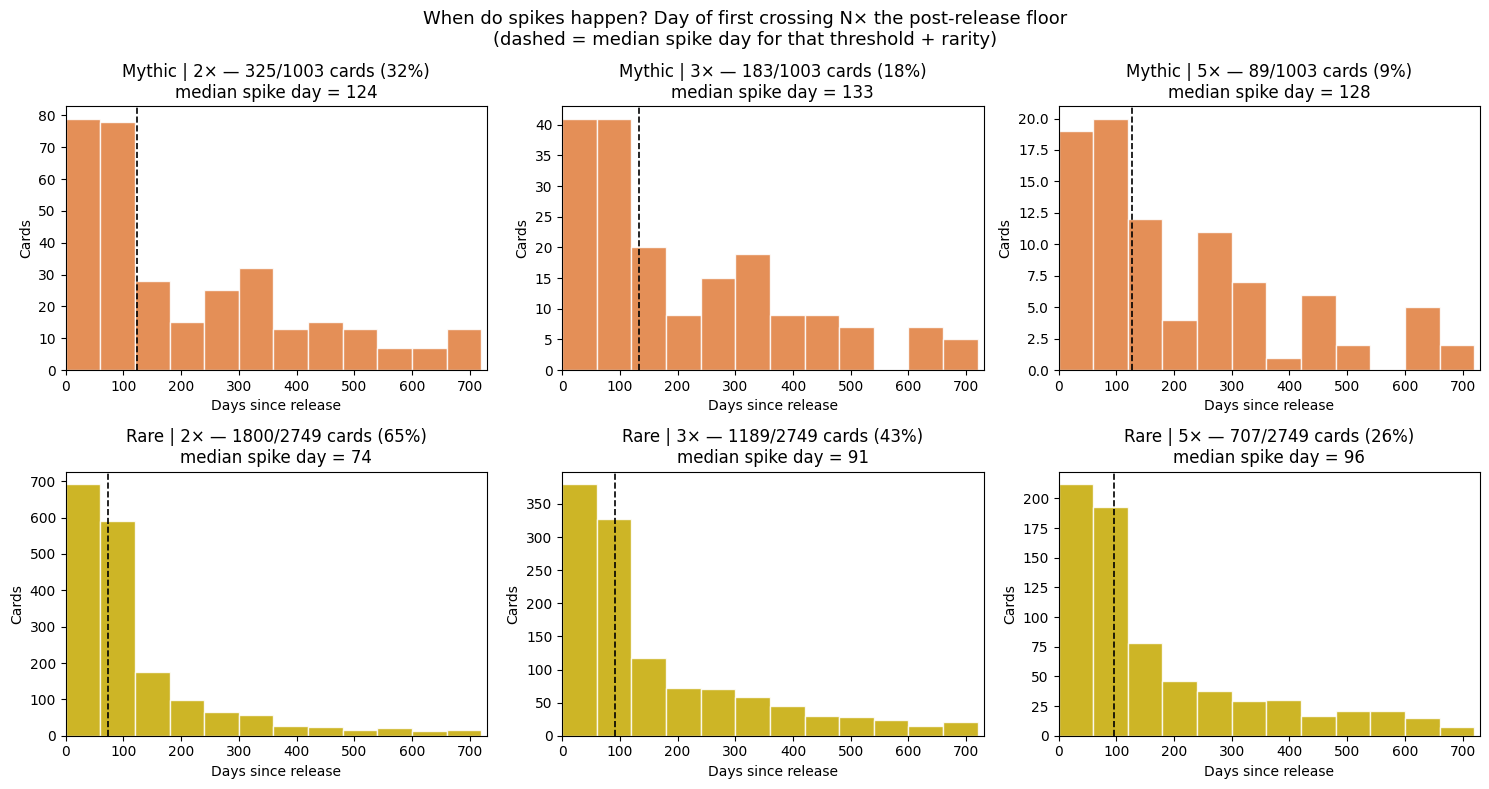

In [15]:
# Figure B — Spike timing: when does the first crossing happen?
# 2×3 grid: rows = rarity, cols = threshold
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)

for col, thresh in enumerate(SPIKE_THRESHOLDS):
    col_key = f"spike_{int(thresh)}x"
    day_key = f"spike_{int(thresh)}x_day"
    for row, rarity in enumerate(RARITY_ORDER):
        ax = axes[row][col]
        total   = len(spikes[spikes["rarity_name"] == rarity])
        spikers = spikes[(spikes["rarity_name"] == rarity) & spikes[col_key]]
        if spikers.empty:
            ax.text(0.5, 0.5, "No spikes", ha="center", va="center", transform=ax.transAxes)
            continue
        days = spikers[day_key].dropna()
        ax.hist(days, bins=range(0, 735, 60),
                color=RARITY_COLORS[rarity], edgecolor="white", alpha=0.85)
        med_day = int(days.median())
        ax.axvline(med_day, color="black", linestyle="--", linewidth=1.2)
        n = len(spikers)
        ax.set_title(
            f"{rarity.capitalize()} | {int(thresh)}\u00d7 — {n}/{total} cards ({n/total*100:.0f}%)\n"
            f"median spike day = {med_day}"
        )
        ax.set_xlabel("Days since release")
        ax.set_ylabel("Cards")
        ax.set_xlim(0, 730)

fig.suptitle(
    "When do spikes happen? Day of first crossing N\u00d7 the post-release floor\n"
    "(dashed = median spike day for that threshold + rarity)",
    fontsize=13,
)
plt.tight_layout()
plt.savefig(DATA_DIR / "spike_figB_timing.png", dpi=150)
plt.show()

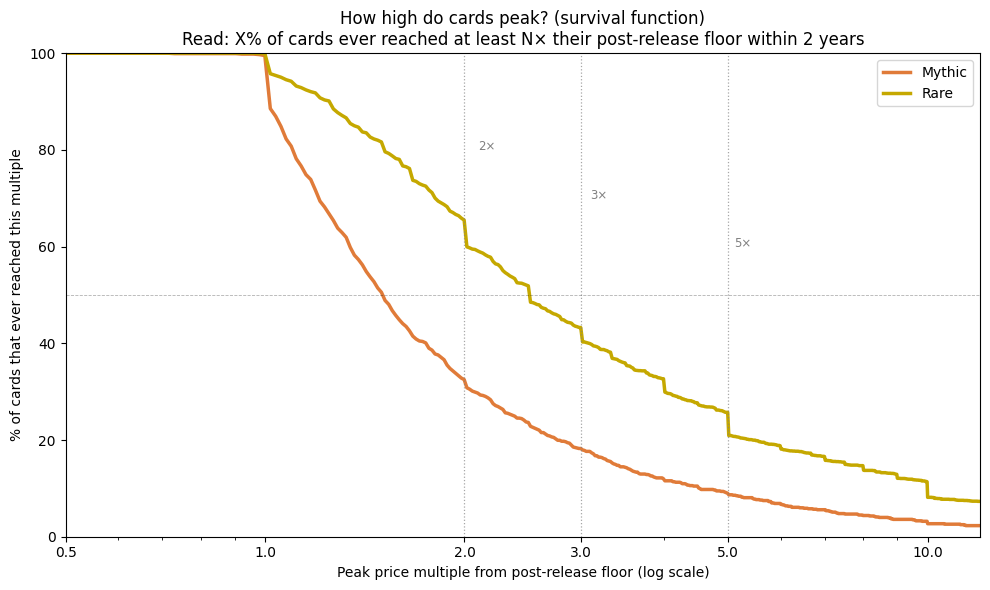

In [16]:
# Figure C — Max ratio survival function
# For every card, max_ratio = highest smoothed price reached / post-release floor.
# Plotted as a complementary CDF: "what % of cards ever reached at least X×?"
# Read the curve at X=3 → Y = probability a random rare will ever 3× from its floor.

fig, ax = plt.subplots(figsize=(10, 6))
x_vals = np.linspace(0.5, 12, 600)

for rarity in RARITY_ORDER:
    sub = spikes[spikes["rarity_name"] == rarity]["max_ratio"].dropna()
    surv = np.array([(sub >= x).mean() * 100 for x in x_vals])
    ax.plot(x_vals, surv, color=RARITY_COLORS[rarity], linewidth=2.5, label=rarity.capitalize())

for thresh, label_y in [(2, 82), (3, 72), (5, 62)]:
    ax.axvline(thresh, color="grey", linestyle=":", linewidth=0.9, alpha=0.7)
    ax.text(thresh + 0.1, label_y, f"{thresh}\u00d7", fontsize=8.5, color="grey", va="top")

ax.axhline(50, color="black", linestyle="--", linewidth=0.6, alpha=0.3)
ax.set_xlabel("Peak price multiple from post-release floor (log scale)")
ax.set_ylabel("% of cards that ever reached this multiple")
ax.set_title(
    "How high do cards peak? (survival function)\n"
    "Read: X% of cards ever reached at least N\u00d7 their post-release floor within 2 years"
)
ax.set_xscale("log")
ax.set_xlim(0.5, 12)
ax.set_ylim(0, 100)
ax.set_xticks([0.5, 1, 2, 3, 5, 10])
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(DATA_DIR / "spike_figC_max_ratio.png", dpi=150)
plt.show()

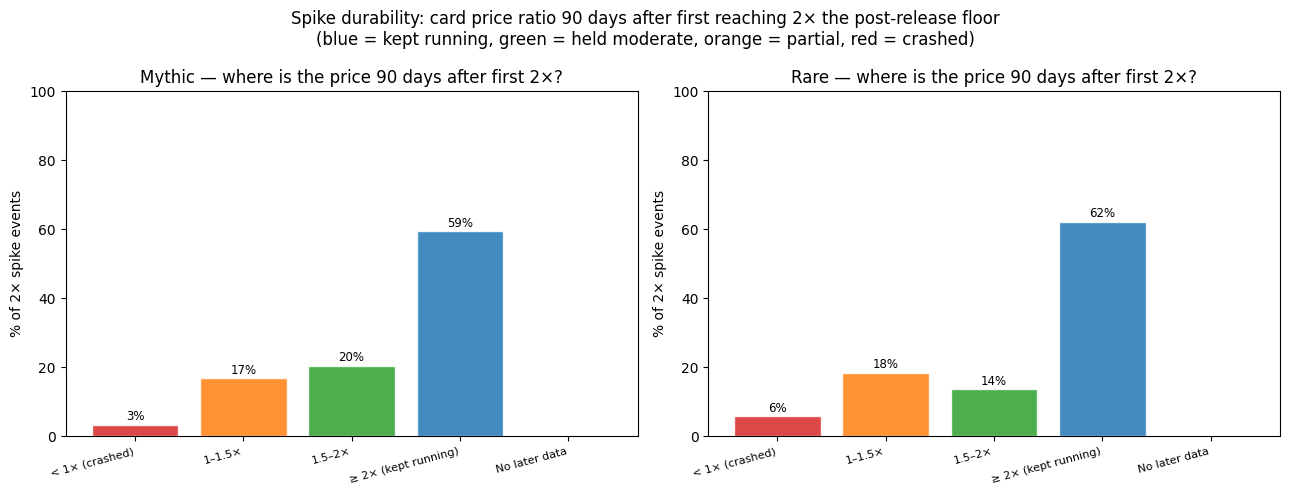


--- Durability summary ---
  Mythic  : 80% still at ≥1.5×, 3% crashed below floor after 90 days
  Rare    : 76% still at ≥1.5×, 6% crashed below floor after 90 days


In [33]:
# Figure D — Spike durability
# For cards that first crossed 2×, what is their price ratio 90 days later?
# Reveals whether 2× spikes are sustained (format staples) or flash bubbles.

LOOK_AHEAD = 90

spiked_2x = (
    spikes[spikes["spike_2x"]]
    [["set_code", "card_version_id", "rarity_name", "spike_2x_day"]]
    .merge(bottoms[["set_code", "card_version_id", "bottom_cents"]], on=["set_code", "card_version_id"])
    .copy()
)
spiked_2x["target_day"] = spiked_2x["spike_2x_day"] + LOOK_AHEAD

# Find the post-bottom row closest to (but not before) target_day for each card
look_df = spiked_2x.merge(
    post_bottom[["set_code", "card_version_id", "days_since_release", "ratio"]],
    on=["set_code", "card_version_id"],
    how="left",
)
look_df = look_df[look_df["days_since_release"] >= look_df["target_day"]].copy()
look_df["day_gap"] = look_df["days_since_release"] - look_df["target_day"]
look_df = (
    look_df.sort_values("day_gap")
    .groupby(["set_code", "card_version_id"])
    .first()
    .reset_index()
)

def ratio_bucket(r):
    if pd.isna(r):  return "No later data"
    if r < 1.0:     return "< 1\u00d7 (crashed)"
    if r < 1.5:     return "1\u20131.5\u00d7"
    if r < 2.0:     return "1.5\u20132\u00d7"
    return "\u2265 2\u00d7 (kept running)"

BUCKET_ORDER  = ["< 1\u00d7 (crashed)", "1\u20131.5\u00d7", "1.5\u20132\u00d7", "\u2265 2\u00d7 (kept running)", "No later data"]
BUCKET_COLORS = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4", "#9e9e9e"]

look_df["bucket"] = look_df["ratio"].apply(ratio_bucket)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, rarity in enumerate(RARITY_ORDER):
    ax = axes[i]
    sub = look_df[look_df["rarity_name"] == rarity]
    counts = sub["bucket"].value_counts().reindex(BUCKET_ORDER, fill_value=0)
    pcts   = counts / counts.sum() * 100
    bars = ax.bar(range(len(BUCKET_ORDER)), pcts, color=BUCKET_COLORS, edgecolor="white", alpha=0.85)
    for bar, v in zip(bars, pcts):
        if v > 1:
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f"{v:.0f}%",
                    ha="center", va="bottom", fontsize=8.5)
    ax.set_xticks(range(len(BUCKET_ORDER)))
    ax.set_xticklabels(BUCKET_ORDER, rotation=15, ha="right", fontsize=8)
    ax.set_ylabel("% of 2\u00d7 spike events")
    ax.set_title(f"{rarity.capitalize()} — where is the price {LOOK_AHEAD} days after first 2\u00d7?")
    ax.set_ylim(0, 100)

fig.suptitle(
    f"Spike durability: card price ratio {LOOK_AHEAD} days after first reaching 2\u00d7 the post-release floor\n"
    "(blue = kept running, green = held moderate, orange = partial, red = crashed)",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(DATA_DIR / "spike_figD_durability.png", dpi=150)
plt.show()

print("\n--- Durability summary ---")
for rarity in RARITY_ORDER:
    sub = look_df[look_df["rarity_name"] == rarity].dropna(subset=["ratio"])
    held = (sub["ratio"] >= 1.5).mean() * 100
    crashed = (sub["ratio"] < 1.0).mean() * 100
    print(f"  {rarity.capitalize():8s}: {held:.0f}% still at \u22651.5\u00d7, {crashed:.0f}% crashed below floor after 90 days")

In [34]:
# Final summary — key numbers per rarity
print("=" * 60)
print("SUMMARY: Long-run spike odds for expansion rares and mythics")
print("=" * 60)
for rarity in RARITY_ORDER:
    sub = spikes[spikes["rarity_name"] == rarity]
    n = len(sub)
    p2 = sub["spike_2x"].mean() * 100
    p3 = sub["spike_3x"].mean() * 100
    p5 = sub["spike_5x"].mean() * 100
    med_max = sub["max_ratio"].median()
    p90_max = sub["max_ratio"].quantile(0.90)
    print(f"\n{rarity.upper()} (n={n:,})")
    print(f"  2\u00d7 from floor: {p2:.1f}% of cards")
    print(f"  3\u00d7 from floor: {p3:.1f}% of cards")
    print(f"  5\u00d7 from floor: {p5:.1f}% of cards")
    print(f"  Median peak multiple: {med_max:.2f}\u00d7")
    print(f"  90th percentile peak: {p90_max:.2f}\u00d7  (top 10% of cards reach this)")

SUMMARY: Long-run spike odds for expansion rares and mythics

MYTHIC (n=1,003)
  2× from floor: 32.4% of cards
  3× from floor: 18.2% of cards
  5× from floor: 8.9% of cards
  Median peak multiple: 1.50×
  90th percentile peak: 4.51×  (top 10% of cards reach this)

RARE (n=2,749)
  2× from floor: 65.5% of cards
  3× from floor: 43.3% of cards
  5× from floor: 25.7% of cards
  Median peak multiple: 2.50×
  90th percentile peak: 10.00×  (top 10% of cards reach this)


---

## Part 4 — Conditional Spike Probability

**Research question:** Given that a card is X days post-release and *hasn't spiked yet*, how likely is it to spike within the next Y days?

This is a **conditional survival analysis** problem. The quantity we want is:

> **P(spike by day X+Y | card is at day X and hasn't spiked yet)**

This is fundamentally different from the unconditional rates in Part 2. A card that hasn't spiked by day 400 is almost certainly bulk — conditioning on survival to that point makes the forward probability much lower than the raw 32%/65% headline numbers.

**Method:** For every combination of observation day X and horizon Y, we identify the **at-risk pool** — cards that:
1. Have already reached their post-release bottom (`bottom_day ≤ X`) — they're in play
2. Are still observable at day X (`max_day ≥ X`) — not right-censored yet
3. Haven't spiked yet at day X — still waiting

We then count how many of those cards spike before day X+Y.

**Note on right-censoring:** Cards from recent sets have fewer than 730 days of data (`max_day < 730`). The `max_day ≥ obs` filter drops them from the pool once we've run out of observations — this is the standard right-censoring correction from survival analysis and prevents the denominator from being inflated by cards we simply can't observe yet.

In [35]:
import itertools

COND_THRESHOLD = "2x"   # change to "3x" or "5x" to study other multiples
OBS_DAYS  = range(0, 660, 30)
HORIZONS  = [30, 60, 90, 180, 365]
MIN_AT_RISK = 10        # skip cells with fewer cards to avoid noisy estimates

# merge spikes with bottom_day and max_day
df_cond = spikes.merge(
    bottoms[["set_code", "card_version_id", "bottom_day", "max_day"]],
    on=["set_code", "card_version_id"],
    suffixes=("", "_b"),
)
df_cond["max_day"] = df_cond[["max_day", "max_day_b"]].max(axis=1)
df_cond = df_cond.drop(columns=["max_day_b"])

spike_col = f"spike_{COND_THRESHOLD}"
day_col   = f"spike_{COND_THRESHOLD}_day"

rows = []
for rarity, obs, h in itertools.product(RARITY_ORDER, OBS_DAYS, HORIZONS):
    pool = df_cond[df_cond["rarity_name"] == rarity]
    at_risk = pool[
        (pool["bottom_day"] <= obs) &
        (pool["max_day"]   >= obs) &
        (~pool[spike_col] | (pool[day_col] > obs))
    ]
    if len(at_risk) < MIN_AT_RISK:
        continue
    will_spike = at_risk[at_risk[spike_col] & (at_risk[day_col] <= obs + h)]
    rows.append({
        "rarity_name": rarity,
        "obs_day":     obs,
        "horizon":     h,
        "prob":        len(will_spike) / len(at_risk),
        "n":           len(at_risk),
    })

cond = pd.DataFrame(rows)
print(f"Grid cells computed: {len(cond)}  (threshold: {COND_THRESHOLD})")
print(cond.groupby(["rarity_name", "horizon"])["prob"].mean().unstack("horizon").round(3))

Grid cells computed: 220  (threshold: 2x)
horizon        30     60     90     180    365
rarity_name                                   
mythic       0.035  0.053  0.070  0.102  0.145
rare         0.071  0.103  0.127  0.176  0.222


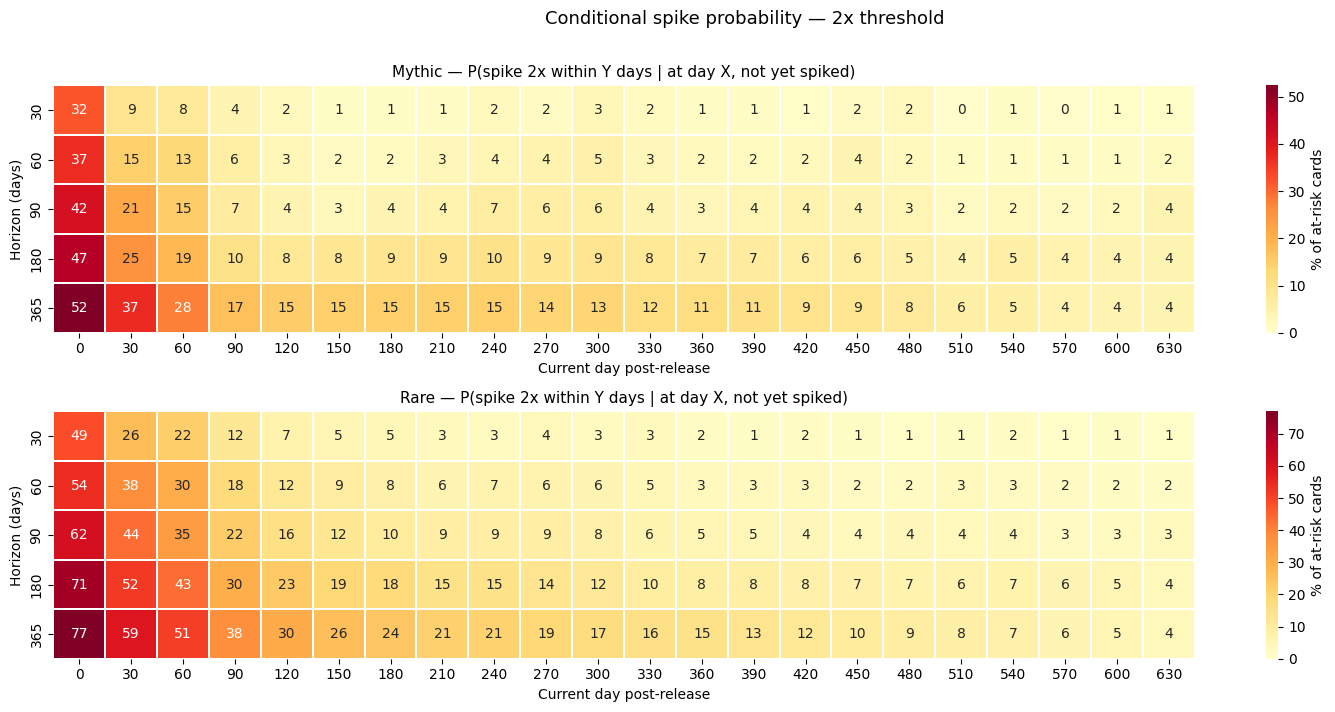

In [36]:
# Figure E — Conditional spike probability heatmap, split by rarity
import seaborn as sns

fig, axes = plt.subplots(2, 1, figsize=(15, 7))
for ax, rarity in zip(axes, RARITY_ORDER):
    sub = cond[cond["rarity_name"] == rarity]
    pivot = sub.pivot(index="horizon", columns="obs_day", values="prob") * 100
    sns.heatmap(
        pivot, ax=ax, cmap="YlOrRd", fmt=".0f", annot=True,
        linewidths=0.3, linecolor="white",
        cbar_kws={"label": "% of at-risk cards"},
        vmin=0, vmax=pivot.max().max(),
    )
    ax.set_title(
        f"{rarity.capitalize()} — P(spike {COND_THRESHOLD} within Y days | at day X, not yet spiked)",
        fontsize=11,
    )
    ax.set_xlabel("Current day post-release")
    ax.set_ylabel("Horizon (days)")

fig.suptitle(f"Conditional spike probability — {COND_THRESHOLD} threshold", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / f"spike_figE_conditional_heatmap_{COND_THRESHOLD}.png", dpi=150, bbox_inches="tight")
plt.show()

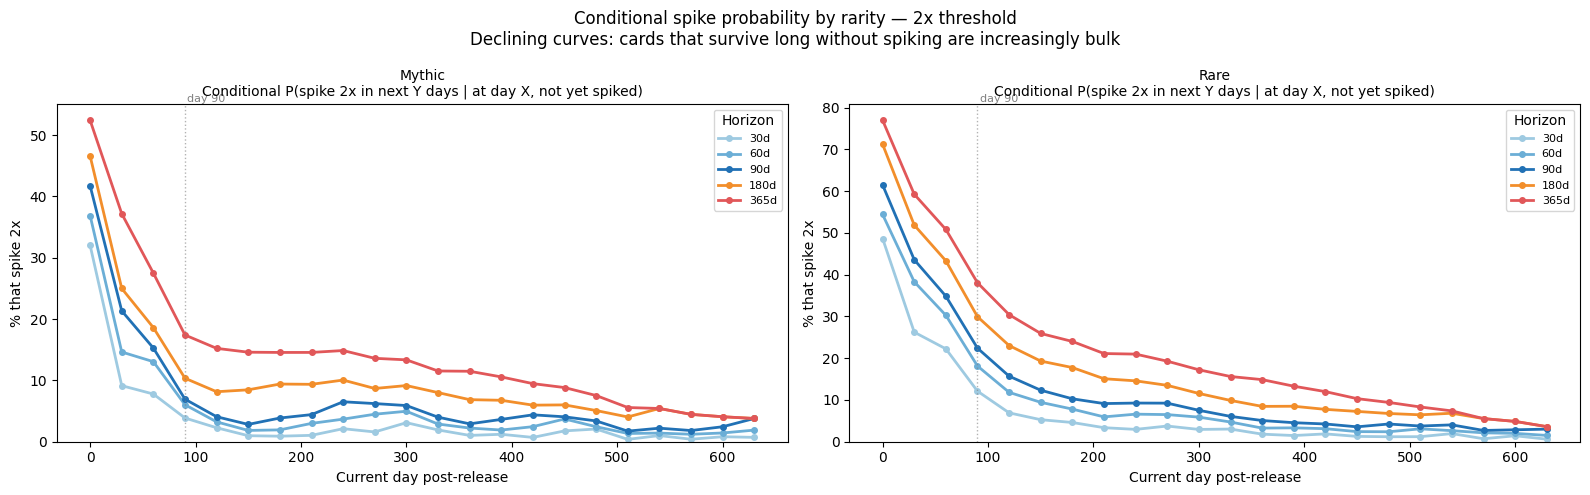


Key read-offs — 90-day horizon, P(spike 2x in next 90d):

  MYTHIC
    Day  90: 6.9%  (n=879)
    Day 180: 3.9%  (n=776)
    Day 270: 6.2%  (n=691)
    Day 450: 4.1%  (n=566)

  RARE
    Day  90: 22.4%  (n=1660)
    Day 180: 10.3%  (n=1216)
    Day 270: 9.2%  (n=985)
    Day 450: 3.6%  (n=785)


In [37]:
# Figure F — Conditional spike probability line plot, split by rarity
HORIZON_COLORS = {30: "#9ecae1", 60: "#6baed6", 90: "#2171b5", 180: "#f28e2b", 365: "#e15759"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
for ax, rarity in zip(axes, RARITY_ORDER):
    sub_r = cond[cond["rarity_name"] == rarity]
    for h in HORIZONS:
        sub = sub_r[sub_r["horizon"] == h].sort_values("obs_day")
        ax.plot(
            sub["obs_day"], sub["prob"] * 100,
            marker="o", markersize=4, linewidth=2,
            color=HORIZON_COLORS[h], label=f"{h}d",
        )
    ax.axvline(90, color="grey", linestyle=":", linewidth=1, alpha=0.6)
    ax.text(92, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 5,
            "day 90", fontsize=8, color="grey", va="bottom")
    ax.set_title(
        f"{rarity.capitalize()}\n"
        f"Conditional P(spike {COND_THRESHOLD} in next Y days | at day X, not yet spiked)",
        fontsize=10,
    )
    ax.set_xlabel("Current day post-release")
    ax.set_ylabel(f"% that spike {COND_THRESHOLD}")
    ax.set_ylim(0, None)
    ax.legend(title="Horizon", fontsize=8)

fig.suptitle(
    f"Conditional spike probability by rarity — {COND_THRESHOLD} threshold\n"
    "Declining curves: cards that survive long without spiking are increasingly bulk",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(DATA_DIR / f"spike_figF_conditional_lines_{COND_THRESHOLD}.png", dpi=150)
plt.show()

print(f"\nKey read-offs — 90-day horizon, P(spike {COND_THRESHOLD} in next 90d):")
for rarity in RARITY_ORDER:
    print(f"\n  {rarity.upper()}")
    sub90 = cond[(cond["rarity_name"] == rarity) & (cond["horizon"] == 90)].sort_values("obs_day")
    for _, row in sub90[sub90["obs_day"].isin([90, 180, 270, 365, 450])].iterrows():
        print(f"    Day {int(row['obs_day']):>3d}: {row['prob']*100:.1f}%  (n={int(row['n'])})")